In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algorithm/sales data.csv')
data.head()
# Channel: 고객 채널(호텔/레스토랑/카페) 또는 소매 채널(명목형 데이터)
# Region: 고객 지역(명목형 데이터)
# Fresh: 신선한 제품에 대한 연간 지출(연속형 데이터)
# Milk: 유제품에 대한 연간 지출(연속형 데이터)
# Grocery: 식료품에 대한 연간 지출(연속형 데이터)
# Frozen: 냉동 제품에 대한 연간 지출(연속형 데이터)
# Detergents_Paper: 세제 및 종이 제품에 대한 연간 지출(연속형 데이터)
# Delicassen: 조제 식품에 대한 연간 지출(연속형 데이터)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [8]:
categorical_features = ['Channel', 'Region'] # 명목형 변수(수치적 크기 의미가 없는 분류용)
continuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] # 연속형 변수(수치 데이터)

for col in categorical_features:
  # pd.get_dummies: 특정 컬럼의 고유값들을 각각 새로운 칼럼으로 만들고, 해당하면 1 아니면 0을 채움
  # prefix=col: 새로 생기는 컬럼명 앞에 원래 컬럼 이름을 붙임(ex: Channel_1, Channel_2)
  dummies = pd.get_dummies(data[col], prefix=col)
  # pd.concat: 인코딩된 더미 변수(0, 1 데이터)를 기존 데이터프레임 오른쪽에 합침
  data = pd.concat([data, dummies], axis=1)
  # drop: 인코딩이 완료된 원본 범주형 컬럼은 더 이상 필요 없으므로 삭제
  data.drop(col, axis=1, inplace=True)
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,True
4,22615,5410,7198,3915,1777,5185,False,True,False,False,True


In [10]:
# MinMaxScaler 객체 생성
# 모든 데이터를 0(최솟값)에서 1(최댓값) 사이로 변환하도록 설정
mms = MinMaxScaler()

# 데이터 학습(fit)
# 데이터프레임의 각 컬럼별로 최솟값(min)과 최댓값(max)을 찾아 계산
mms.fit(data)

# 데이터 변환(transform)
# 계산된 최솟값과 최댓값을 바탕으로 실제 데이터를 0~1 사이로 변환
# 결과물인 data_transformed는 넘파이(NumPy) 배열 형태가 된다.
data_transformed = mms.transform(data)

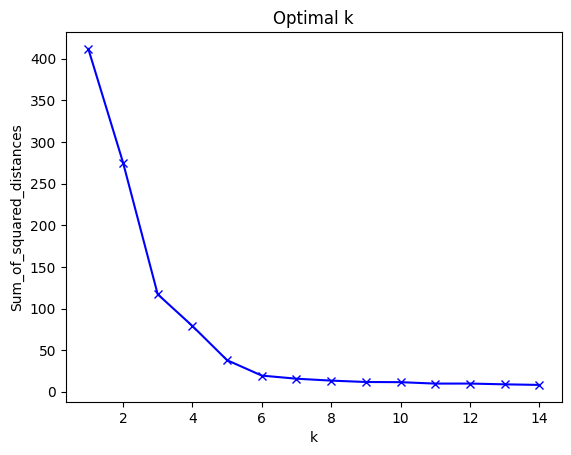

In [12]:
# km.inertia_: 값(군집 내 오차 제곱합)들을 담아두는 바구니
Sum_of_squared_distances = []
K = range(1, 15)
for k in K:
  km = KMeans(n_clusters=k)
  km = km.fit(data_transformed)

  # 학습된 모델의 inertia_(오차 제곱합)를 리스트에 추가
  # 이 값이 작을수룩 군집이 빽빽하게 잘 모여 있다는 뜻이다.
  Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Optimal k')
plt.show()